# Quantization Tutorial

- Quantization is a technique to downsize a trained model so that you can deploy it on EDGE devices. In this tutorial we will,

- (1) Train a hand written digits model

- (2) Export to a disk and check the size of that model

- (3) Use two techniques for quantization (1) post training quantization (3) quantization aware training

In [28]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [29]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
len(X_train)

60000

In [4]:
len(X_test)

10000

In [5]:
X_train[0].shape

(28, 28)

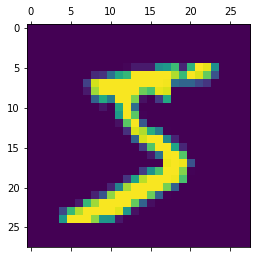

In [6]:
plt.matshow(X_train[0])

In [7]:
y_train[0]

5

In [8]:
X_train = X_train / 255
X_test = X_test / 255

In [10]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [11]:
X_train_flattened.shape

(60000, 784)

## Using Flatten layer so that we don't have to call .reshape on input dataset

In [12]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2692 - accuracy: 0.9246
Epoch 2/5
1875/1875 [==============================] - 2s 998us/step - loss: 0.1243 - accuracy: 0.9634
Epoch 3/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0869 - accuracy: 0.9740
Epoch 4/5
1875/1875 [==============================] - 2s 997us/step - loss: 0.0666 - accuracy: 0.9803
Epoch 5/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0516 - accuracy: 0.9840


In [13]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 0s 817us/step - loss: 0.0831 - accuracy: 0.9753


[0.08312996476888657, 0.9753000140190125]

In [14]:
model.save("./saved_model/")

INFO:tensorflow:Assets written to: ./saved_model/assets


> Checked this saved model size in path. Its almost 1MB, This is simple model, in real life model will be very big

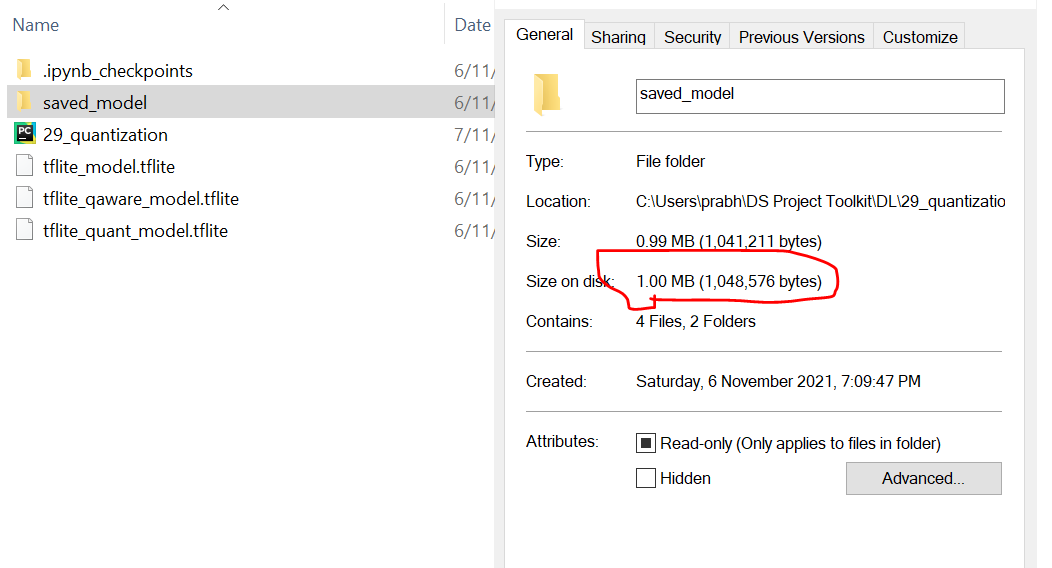

### (1) Post training quantization

- Without quantization
- Here we read saved model and apply tf.lite and converts

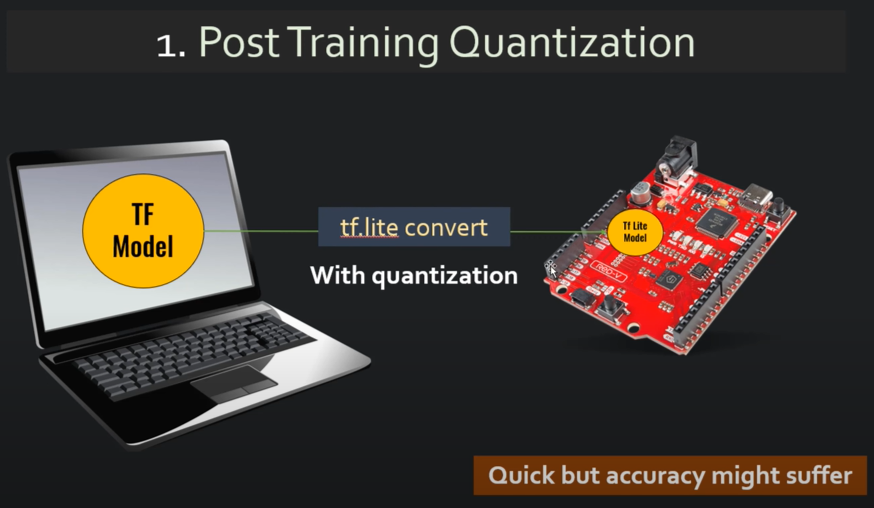

In [31]:
converter = tf.lite.TFLiteConverter.from_saved_model("./saved_model")
tflite_model = converter.convert()

> Here tflite_model is the tflite converted model without quantization

- **With quantization**

- Here just add **.optimizations** this will converts it to quantized model

- Here below script is just quantizing the **weights**, this way in another script we can quantize **activation** also


In [36]:
converter = tf.lite.TFLiteConverter.from_saved_model("./saved_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

> Read this article for post training quantization: https://www.tensorflow.org/model_optimization/guide/quantization/post_training

In [37]:
len(tflite_model)

319792

In [18]:
len(tflite_quant_model)

84752

> You can see above that quantizated model is 1/4th the size of a non quantized model

> Now the size reduced a lot from 319792 bytes to 84752 bytes

### Save both the model, "without quantization" and "with quantization"

In [39]:
with open("tflite_model.tflite", "wb") as f:
    f.write(tflite_model)

In [40]:
with open("tflite_quant_model.tflite", "wb") as f:
    f.write(tflite_quant_model)

> Once you have above files saved to a disk, check their sizes. Quantized model will be obviously very less, earlier its almost 83KB, now 

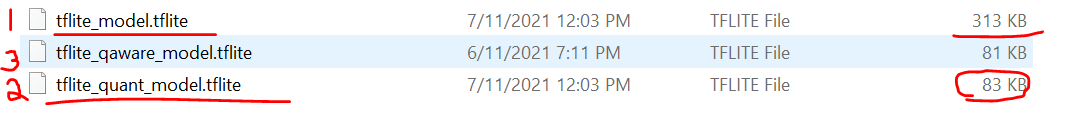

### (2) Quantization aware training

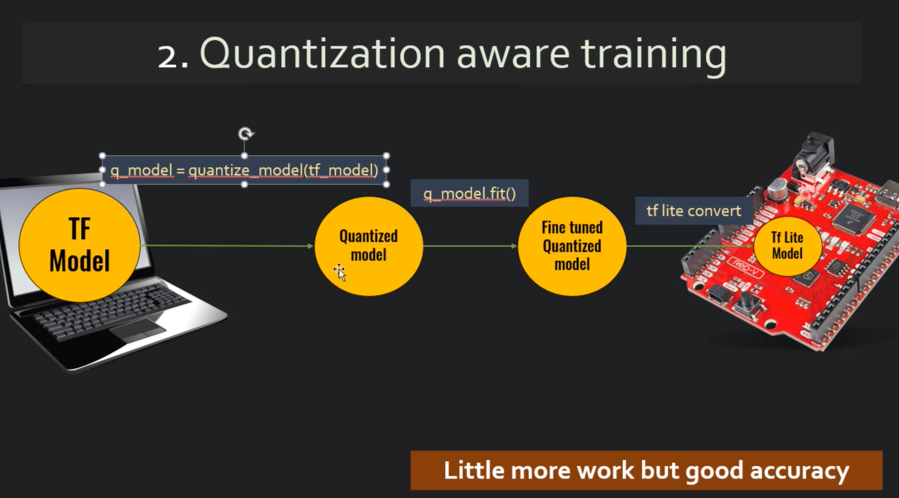

In [41]:
import tensorflow_model_optimization as tfmot

quantize_model = tfmot.quantization.keras.quantize_model

# q_aware stands for for quantization aware.
# Apply quantize_model to trained model "model"
q_aware_model = quantize_model(model)

# `quantize_model` requires a recompile.

#Compile the model
q_aware_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

q_aware_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
quantize_layer_1 (QuantizeLa (None, 28, 28)            3         
_________________________________________________________________
quant_flatten (QuantizeWrapp (None, 784)               1         
_________________________________________________________________
quant_dense (QuantizeWrapper (None, 100)               78505     
_________________________________________________________________
quant_dense_1 (QuantizeWrapp (None, 10)                1015      
Total params: 79,524
Trainable params: 79,510
Non-trainable params: 14
_________________________________________________________________


In [23]:
# Here quantization applied model trained again atleast with 1 epoch
q_aware_model.fit(X_train, y_train, epochs=1)

1875/1875 [==============================] - 3s 2ms/step - loss: 0.0445 - accuracy: 0.9861


In [24]:
q_aware_model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.0838 - accuracy: 0.9756


[0.08377649635076523, 0.975600004196167]

In [42]:
#Earlier while convert we used "from_saved_model" to read model from disk, now we are reading from in memory so we use "from_keras_model"
converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
#Apply quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_qaware_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\prabh\AppData\Local\Temp\tmp9_8o0hqy\assets


INFO:tensorflow:Assets written to: C:\Users\prabh\AppData\Local\Temp\tmp9_8o0hqy\assets


In [26]:
len(tflite_qaware_model)

82376

In [27]:
with open("tflite_qaware_model.tflite", 'wb') as f:
    f.write(tflite_qaware_model)

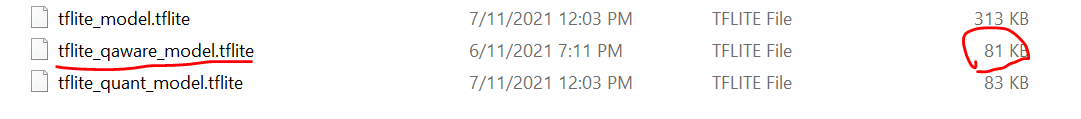